In [ ]:
# !pip install --upgrade -q scikit-learn pycaret xgboost

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as pt
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Read in training data

import pandas as pd

# Replace with your Google Drive shareable link
drive_url = "https://drive.google.com/file/d/122kxiprQhzR123mGnyGxSERg854FmbBF/view?usp=sharing"

# Convert the Google Drive URL to a direct download URL
file_id = drive_url.split('/d/')[1].split('/')[0]
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the CSV file into a DataFrame
df = pd.read_csv(download_url)

# Display the first few rows of the DataFrame
print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
# Read in test data

import pandas as pd

# Replace with your Google Drive shareable link
drive_url = "https://drive.google.com/file/d/1qZIgsTvpF4acFXosreetuGZyYaOjhSgM/view?usp=sharing"
# Convert the Google Drive URL to a direct download URL
file_id = drive_url.split('/d/')[1].split('/')[0]
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the CSV file into a DataFrame
df_test = pd.read_csv(download_url)

# Display the first few rows of the DataFrame
print(df_test.head())


   age  sex        bmi  children  smoker  region
0   58    0  30.338722         0       0       1
1   60    0  24.324606         0       0       0
2   27    0  18.228846         3       0       1
3   24    0  40.426077         0       1       2
4   19    0  35.872515         0       0       0


In [29]:
# Inspect columns and confirm target
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
#Check column data types
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [8]:
#Objects mast be converted to numbers
#Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

#Copy df so we don't overwrite original
df_encode = df.copy()
df_test_encode = df_test.copy()

#Columns that need encoding
cat_cols = ['sex','smoker','region']

le = LabelEncoder()

for col in cat_cols:
  df_encode[col] = le.fit_transform(df_encode[col])
  df_test_encode[col] = le.fit_transform(df_test_encode[col])

In [9]:
#Redefine X and y using the encoded data
X = df_encode.drop('charges', axis=1)
y = df_encode['charges']

In [10]:
#Split, train, and evaluate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_vale, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_val_pred = lin_reg.predict(X_vale)

mse = mean_squared_error(y_val, y_val_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 33635210.431178406


In [24]:
# Create submit.csv on local drive for submission to Kaggle competition

import pandas as pd

# Assuming final_model is your trained model and X_test is your test dataset
# Generate predictions
predictions = lin_reg.predict(df_test)

# Create a DataFrame with ID and TARGET columns
submission_df = pd.DataFrame({
    'ID': range(1, len(df_test) + 1),
    'TARGET': predictions
})

# Save to submit.csv
submission_df.to_csv('submit.csv', index=False)

print("submit.csv file created successfully!")

# # Download the CSV file to local machine
# files.download('submit.csv')



submit.csv file created successfully!


In [18]:
#Re-run your train/validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#Improve Score with Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [20]:
#Fit the model
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [21]:
#Validate using MSE
from sklearn.metrics import mean_squared_error

y_val_pred = rf.predict(X_val)
mse = mean_squared_error(y_val, y_val_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 20778721.787278876


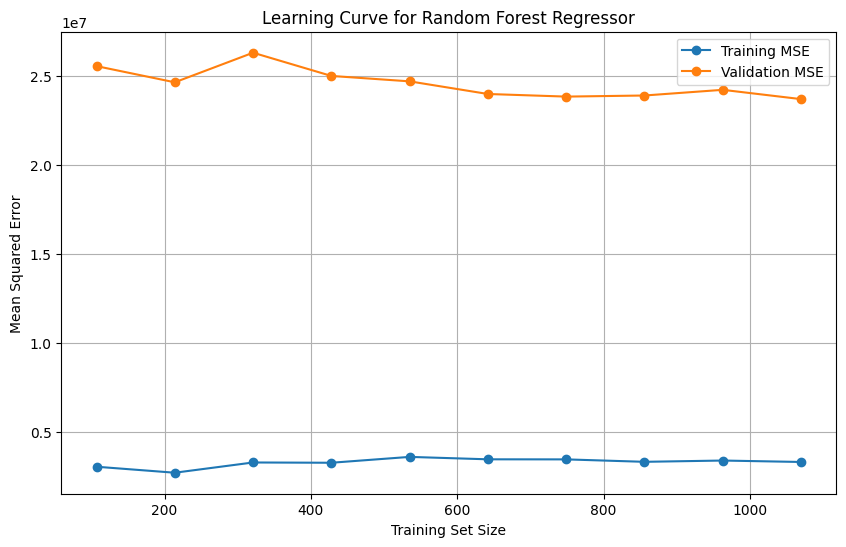

In [28]:
#Learning Curve Visualization
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

#Generate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf,
    X=X,
    y=y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

#Convert negative MSE to positive

train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)

#Plot the learning curve

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mse, marker='o', label='Training MSE')
plt.plot(train_sizes, val_mse, marker='o', label='Validation MSE')

plt.title('Learning Curve for Random Forest Regressor')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
#Retrain on full training data
rf.fit(X, y)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [23]:
#Predict on the test set
test_predictions = rf.predict(df_test_encoded)

In [27]:
# Create submit.csv on local drive for submission to Kaggle competition

import pandas as pd

# Generate predictions using the Random Forest model on the encoded test set
predictions = rf.predict(df_test_encoded)

# Create a DataFrame with ID and TARGET columns
# Since your test set has no ID column, we use the index as the ID
submission_df = pd.DataFrame({
    'ID': range(1, len(df_test_encoded) + 1),
    'TARGET': predictions
})

# Save to submit.csv
submission_df.to_csv('RFsubmit.csv', index=False)

print("submit.csv file created successfully!")

submit.csv file created successfully!
